In [ ]:
# Experiment 5 — Scalable Kernel Approximations
# Motivation
# Exact kernel ridge regression can be computationally expensive for large fit sets. We benchmark Nystrom and Random Fourier Feature approximations under a governance lens: speed is useful only if ranking-level decisions remain stable.  

# $$
# \varepsilon_{\mathrm{approx}}=\left|\hat U_t^{\mathrm{approx}}-\hat U_t^{\mathrm{exact}}\right|.
# $$
# $$
# \rho_s=\mathrm{corr}_{\mathrm{rank}}\Big(\{\hat U_t^{\mathrm{approx}}\}_t,\{\hat U_t^{\mathrm{exact}}\}_t\Big).
# $$
import matplotlib.pyplot as plt
import seaborn as sns

# 科研级图表全局设置
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.frameon": False,
    "figure.figsize": (7, 4.5),
    "figure.dpi": 150,
    "mathtext.fontset": "dejavuserif"
})

from pathlib import Path
import numpy as np
import pandas as pd
art_dir = Path('../results/artifacts').resolve()
art_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# Load table and build ranking/per-target views
csv_path = Path('../results/tables/exp5_scalable_approx.csv').resolve()
df = pd.read_csv(csv_path)

rank_df = df[df['row_kind'] == 'ranking'].copy().sort_values(['method', 'approx_dim'])
per_target = df[df['row_kind'] == 'per_target'].copy()
exact = per_target[per_target['method'] == 'exact'][['target_id', 'kernel_pier_estimate']].rename(columns={'kernel_pier_estimate': 'pier_exact'})
merged = per_target.merge(exact, on='target_id', how='left')
merged['abs_err'] = (merged['kernel_pier_estimate'] - merged['pier_exact']).abs()

curve = (
    merged[merged['method'] != 'exact']
    .groupby(['method', 'approx_dim'], as_index=False)
    .agg(runtime_mean=('runtime_sec', 'mean'), abs_err_mean=('abs_err', 'mean'), abs_err_std=('abs_err', 'std'))
    .sort_values(['method', 'approx_dim'])
)
rank_df.head(), curve.head()

(   row_kind  target_id   method  approx_dim  runtime_sec  \
 4   ranking         -1    exact         NaN     0.031840   
 9   ranking         -1  nystrom        64.0     0.006088   
 14  ranking         -1  nystrom       128.0     0.014925   
 19  ranking         -1  nystrom       256.0     0.046627   
 24  ranking         -1      rff        64.0     0.002503   
 
     kernel_pier_estimate  approx_error_abs  best_lambda  fit_size  eval_size  \
 4               0.016026          0.000000          NaN      1200        400   
 9               0.053664          0.037638          NaN      1200        400   
 14              0.031241          0.015214          NaN      1200        400   
 19              0.024939          0.008913          NaN      1200        400   
 24              0.091427          0.075401          NaN      1200        400   
 
     honesty_fit_size  honesty_eval_size  n_peers  gamma  seed  \
 4               1200                400       16   0.08    11   
 9          

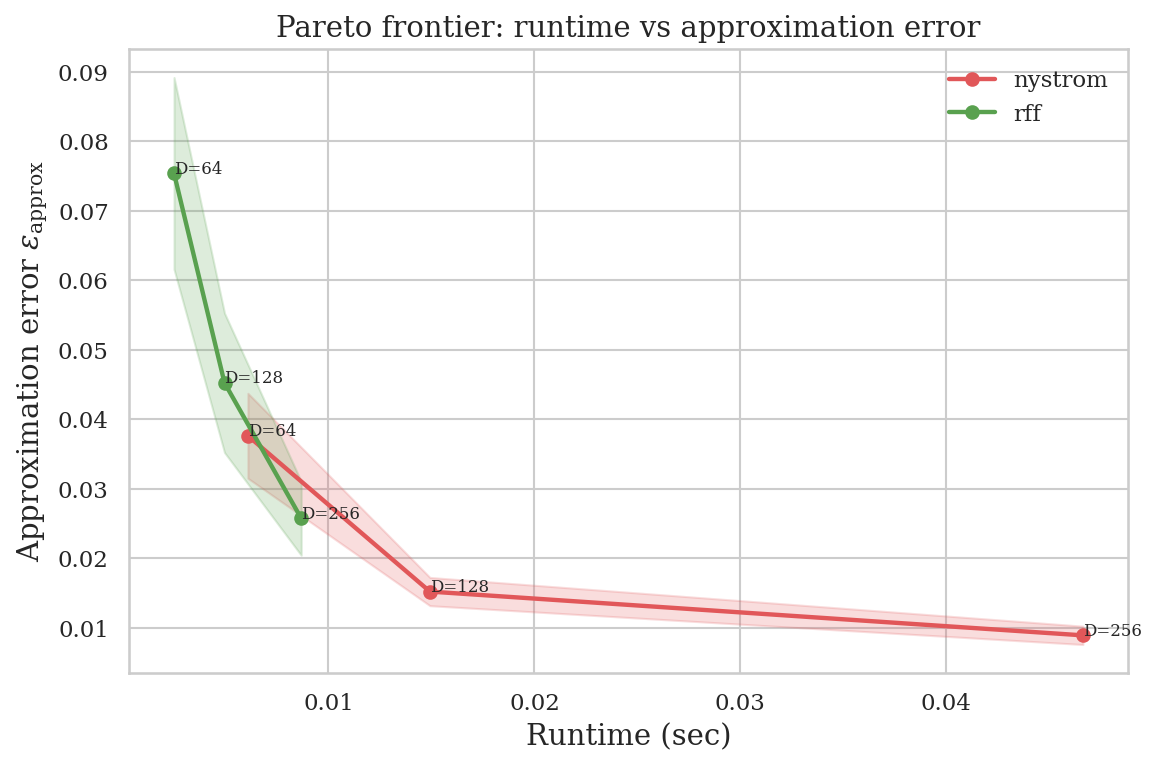

In [ ]:
# Pareto frontier: runtime vs approximation error
fig, ax = plt.subplots(figsize=(8.6, 5.4))
palette = {'nystrom': '#E15759', 'rff': '#59A14F'}

for method, sub in curve.groupby('method'):
    sub = sub.sort_values('approx_dim')
    x = sub['runtime_mean'].to_numpy()
    y = sub['abs_err_mean'].to_numpy()
    s = sub['abs_err_std'].fillna(0.0).to_numpy()
    ax.plot(x, y, marker='o', lw=2.1, color=palette.get(method), label=method)
    ax.fill_between(x, y - s, y + s, alpha=0.2, color=palette.get(method))
    for _, r in sub.iterrows():
        ax.annotate(f"D={int(r['approx_dim'])}", (r['runtime_mean'], r['abs_err_mean']), fontsize=8)

ax.set_xlabel(r'Runtime (sec)')
ax.set_ylabel(r'Approximation error $\varepsilon_{\mathrm{approx}}$')
ax.set_title('Pareto frontier: runtime vs approximation error')
ax.legend(loc='best')
plt.savefig(art_dir / 'exp5_pareto_frontier.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [19]:
rank_df[['method', 'approx_dim', 'runtime_sec', 'approx_error_abs', 'ranking_spearman_vs_exact', 'top1_match_exact']].sort_values(['method', 'approx_dim'])

,method,approx_dim,runtime_sec,approx_error_abs,ranking_spearman_vs_exact,top1_match_exact
4,exact,NaN,0.031840,0.000000,1.0,1.0
9,nystrom,64.0,0.006088,0.037638,1.0,1.0
14,nystrom,128.0,0.014925,0.015214,1.0,1.0
19,nystrom,256.0,0.046627,0.008913,1.0,1.0
24,rff,64.0,0.002503,0.075401,1.0,1.0
29,rff,128.0,0.004953,0.045253,1.0,1.0
34,rff,256.0,0.008677,0.025752,1.0,1.0
